# Prequisite (cukup jalankan sekali)


In [ ]:
import nltk

# nltk.download('stopwords')
# nltk.download('words')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')

# Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import emoji
from wordcloud import WordCloud
import nltk

from collections import Counter
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import chi2, SelectPercentile
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import re
from nltk.corpus import stopwords
from nltk.corpus import words as nltk_words
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


# Data Preview

In [3]:
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [3]:
df.shape

(8175, 2)

In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
print("Rata-rata panjang kata:", round(df['text'].apply(len).mean()))
print("Panjang maksimum kata:", df['text'].apply(len).max())
print("Panjang minimum kata:", df['text'].apply(len).min())


Rata-rata panjang kata: 369
Panjang maksimum kata: 41544
Panjang minimum kata: 2


In [6]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

# Phase

# EDA

### Distribusi noise

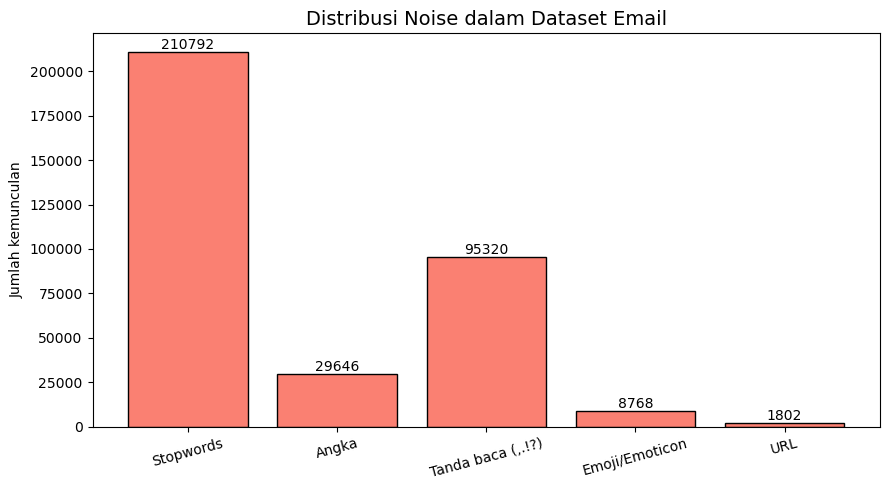

In [4]:
# Extract all words from dataset
all_words = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

# Dictionary of noise count
noise = {
    'Stopwords': sum(all_words.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', all_words)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': len(re.findall(r'http\S+|www\S+', all_words)),
}

# Plot styling
plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Macam Emoji

In [5]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

### Preview bentuk asli noise

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1528004515.py:66: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


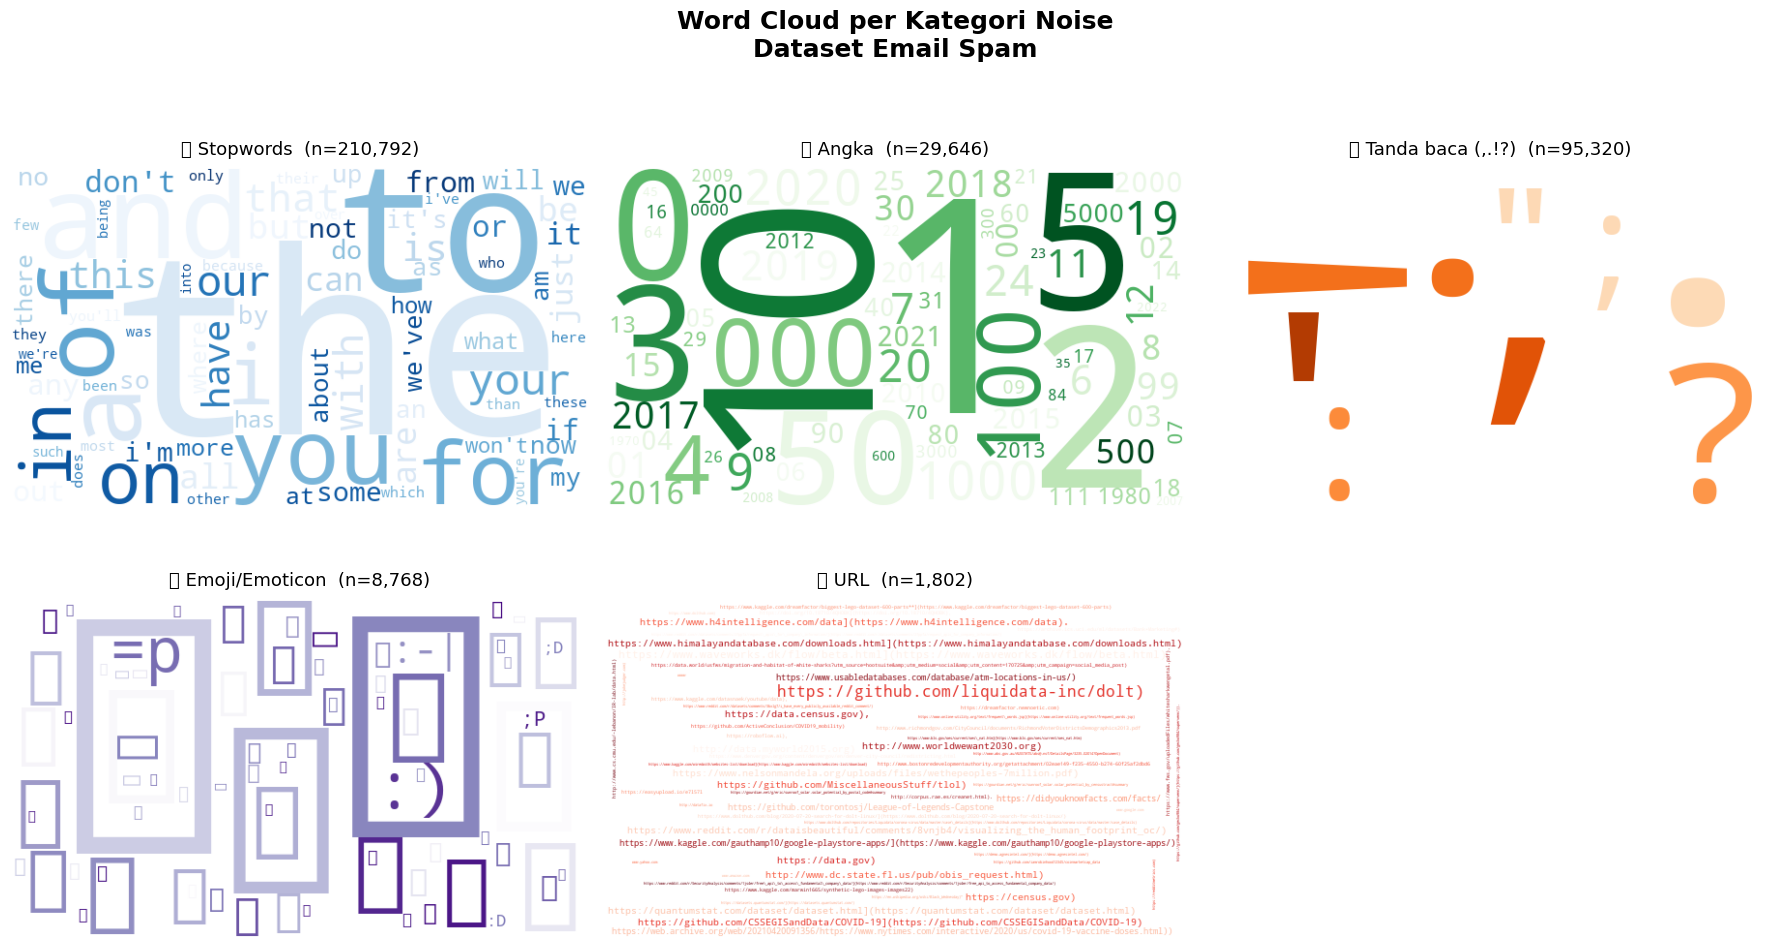

In [6]:
# Tokenisasi per kata
tokens = all_words.lower().split()

# Dictionary of noise frequency count
noise_freq = {
    'Stopwords': Counter(w for w in tokens if w in stopword_en),
    'Angka': Counter(re.findall(r'\b\d+\b', all_words)),
    'Tanda baca (,.!?)': Counter(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': Counter(re.findall(r'http\S+|www\S+', all_words)),
}

# Dictionary of colormap for each noise category
cmap_map = {
    'Stopwords': 'Blues',
    'Angka': 'Greens',
    'Tanda baca (,.!?)': 'Oranges',
    'Emoji/Emoticon': 'Purples',
    'URL': 'Reds',
}

# Function to generate Word Cloud
def make_wc(freq_dict: Counter[str, str], colormap: str, max_words=80):
    """
    Membuat Word Cloud dari frequency dictionary.
    """
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# Layouting
n = len(noise)
ncols = 3
nrows = -(-n // ncols)  


# Plotting Word Cloud
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Cek kata terpanjang, terpendek, dan null

In [7]:
df['text_length'] = df['text'].apply(len) # Tambah kolom panjang kata

<Axes: >

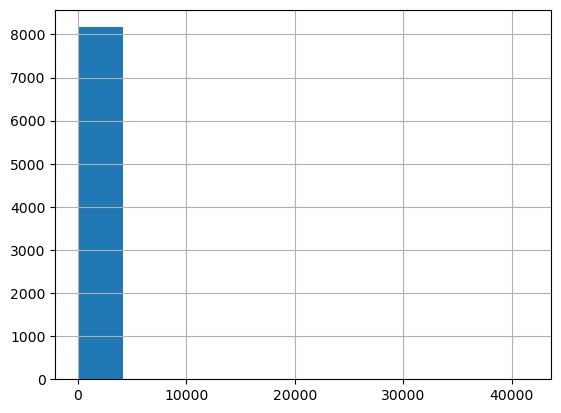

In [8]:
df['text_length'].hist()

In [12]:
df[['text_length']].describe()

,text_length
count,8175.000000
mean,369.111315
std,565.820388
min,2.000000
25%,175.000000
50%,284.000000
75%,507.000000
max,41544.000000


In [9]:
df[df['text_length'] == 41544] # Cek kata terpanjang

,text,label,text_length
6262,I've made a zip code-level data retriever in R...,not_spam,41544


In [10]:
df[df['text_length'] == 0] # Cek kata null

,text,label,text_length


In [11]:
df[df['text_length'] < 10] # Cek kata terpendek (kurang dari 10 character)

,text,label,text_length
1569,^^,not_spam,2
2949,See title,not_spam,9
3142,TIA :),not_spam,6
3687,Title.,not_spam,6
3987,Thanks!,not_spam,7
5765,question,not_spam,8
7788,Thanks,not_spam,6


### Spam vs Non Spam

In [35]:
def extract_noise(text):
    stopword_en = set(stopwords.words('english'))
    words = text.lower().split()

    return pd.Series({
        'stopwords': sum(w in stopword_en for w in words),

        'angka': len(re.findall(r'\d', text)),

        'tanda_baca': len(
            re.findall(r'[,\.!?;:\"\']', text)
        ),

        'emoji': len(
            re.findall(
                r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]',
                text
            )
        ),

        'url': len(
            re.findall(r'http\S+|www\S+', text)
        )
    })

# =========================
# tambah kolom
# =========================
df_corr = df.copy()
df_corr[
    ['stopwords',
     'angka',
     'tanda_baca',
     'emoji',
     'url']
] = df_corr['text'].apply(extract_noise)

df_corr['label'] = df_corr['label'].map({'spam': 1, "not_spam": 0})
df_corr.head()

,text,label,text_length,stopwords,angka,tanda_baca,emoji,url
0,hey I am looking for Xray baggage datasets can...,0,76,9,0,0,0,0
1,"""Get rich quick! Make millions in just days wi...",1,129,9,0,6,0,0
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,46,0,24,0,0
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,35,16,41,0,7
4,Trying to see if anyone already has timestamps...,0,223,19,0,6,0,0


<Axes: >

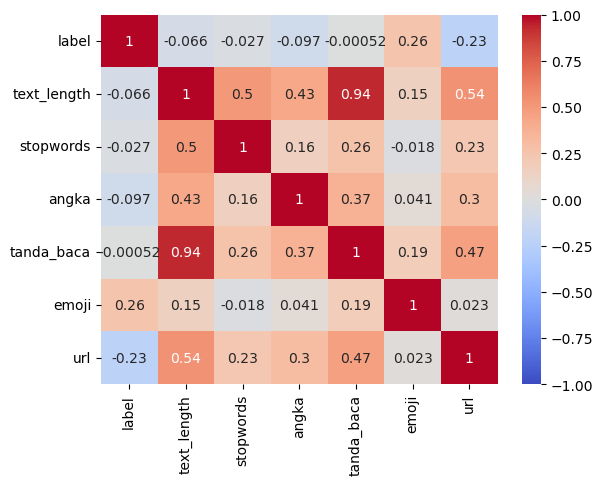

In [ ]:
sns.heatmap(df_corr.select_dtypes(include='number').corr(), annot=True,
            vmin=-1, vmax=1, cmap='coolwarm')

# Masking

In [48]:
def mask_urls(text:str):
    """
    Ganti URL shortener (bit.ly, tinyurl, dst.) → 'shorturltoken'
    dan URL biasa + naked domain → 'urltoken'.
    """
    # Bedakan URL suspicious vs normal
    suspicious_patterns = r'(bit\.ly|tinyurl|goo\.gl|t\.co|shorturl)'
    
    # URL shortener → token khusus
    text = re.sub(
        rf'https?://\S*{suspicious_patterns}\S*', 
        ' shorturltoken ', text, flags=re.IGNORECASE
    )
    
    # URL biasa
    text = re.sub(
        r'https?://\S+', 
        ' urltoken ', text
    )
    
    # Naked domain (tanpa http)
    text = re.sub(
        r'\b(?:www\.)\S+\.\S+', 
        ' urltoken ', text
    )
    
    return text

df['mask_text'] = df['text'].apply(mask_urls)

In [49]:
def mask_currency(text:str):
    """
    Ganti nominal Rp/IDR → 'nominaltoken',
    nominal USD/$  → 'nominaltoken',
    angka besar standalone (≥4 digit) → 'numbertoken'.
    """
    # Format Rp / IDR
    text = re.sub(
        r'Rp\.?\s?[\d.,]+(?:\s?(?:ribu|juta|miliar|rb|jt|M))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Format USD / simbol $
    text = re.sub(
        r'\$\s?[\d.,]+(?:\s?(?:thousand|million|billion))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Angka besar standalone (>= 4 digit) — hati-hati jangan overmask
    text = re.sub(
        r'\b\d{4,}(?:[.,]\d+)*\b',
        ' numbertoken ', text
    )
    
    return text

df['mask_text'] = df['mask_text'].apply(mask_currency)

In [50]:
def normalize_elongation(text:str, max_repeat = 2):
    """
    Normalisasi karakter yang diulang berlebihan.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    
    # Ganti karakter yang muncul > max_repeat kali berturut-turut
    pattern = rf'(.)\1{{{max_repeat},}}'
    return re.sub(pattern, r'\1' * max_repeat, text)

df['mask_text'] = df['mask_text'].apply(normalize_elongation)


In [51]:
df[['mask_text','text']]

,mask_text,text
0,hey I am looking for Xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...","Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,Do you want to BLOW UP your social media follo...


## Casefolding and Normalization

In [52]:
english_words = set(nltk_words.words())

def normalize_elongation_smart(text):
    """
    Normalisasi karakter yang diulang berlebihan, dengan melihat kamus inggris.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    def fix_word(word):
        # Kurangi dulu ke max_repeat=2
        reduced = re.sub(r'(.)\1{2,}', r'\1\1', word)
        
        # Coba kurangi sampai ketemu di dictionary
        for n in range(len(reduced), 0, -1):
            candidate = re.sub(r'(.)\1+', lambda m: m.group(1) * min(len(m.group()), n), reduced)
            if candidate.lower() in english_words:
                return candidate
        
        return reduced  
    
    return ' '.join(fix_word(w) for w in text.split())


df['text_normalized'] = df['mask_text'].apply(normalize_elongation)

# Remove enter (\n)
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

def remove_punctuation(text):
    """
    Hapus punctuation tapi JAGA token masking (urltoken, nominaltoken, dst)
    dan angka yang masih tersisa.
    
    Contoh:
        "Klik urltoken sekarang!!!"     → "Klik urltoken sekarang"
        "Gratis??? Hub. kami 08123..."  → "Gratis Hub kami 08123"
        "harga: Rp.10rb/hari"          → "harga Rp10rbari"  ← (sudah di-mask sebelumnya, nominaltoken hari)
    """
    # Hapus semua karakter selain huruf, angka, dan spasi
    text = re.sub(r'[^\w\s]', '', text)
    
    # Normalisasi spasi ganda hasil hapus punctuation
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['text_normalized'] = df['text_normalized'].apply(remove_punctuation)

#Casefold menjadi lowercase
df['text_normalized'] = df['text_normalized'].str.lower()

#Remove space on start/end character
df['text_normalized'] = df['text_normalized'].str.strip()

# Lemma

In [53]:
lemmatizer = WordNetLemmatizer()
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

def get_wordnet_pos(word:str):
    """
    Map POS tag dari NLTK ke format konstanta WordNet.

    Mengambil kata sebagai input, menentukan POS tag-nya menggunakan NLTK,
    lalu mengembalikan konstanta WordNet yang sesuai untuk digunakan
    dalam proses lemmatization.

    Parameters
    ----------
    word : str
        Kata tunggal yang ingin diketahui POS-nya.

    Returns
    -------
    str
        Konstanta WordNet: wordnet.ADJ, wordnet.VERB, wordnet.NOUN,
        atau wordnet.ADV. Default ke wordnet.NOUN jika tag tidak dikenali.

    Contoh
    --------
    >>> get_wordnet_pos("running")
    'v'  # wordnet.VERB
    >>> get_wordnet_pos("beautiful")
    'a'  # wordnet.ADJ
    >>> get_wordnet_pos("quickly")
    'r'  # wordnet.ADV
    >>> get_wordnet_pos("dog")
    'n'  # wordnet.NOUN
    >>> get_wordnet_pos("xyzabc")  # tag tidak dikenali → default NOUN
    'n'  # wordnet.NOUN
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN) 

def apply_lemmatization(text:str):
    words = text.split()
    result = [
        word if word in MASK_TOKENS
        else lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]
    return ' '.join(result)

df['lemma'] = df['text_normalized'].apply(apply_lemmatization)

# Remove stoprword

In [54]:
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}
BASE_STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    result = [
        word for word in words
        if word in MASK_TOKENS or word not in BASE_STOPWORDS
    ]
    return ' '.join(result)

df['text_remove_sw'] = df['lemma'].apply(remove_stopwords)

In [55]:
df[df['text_length'] == 2] 

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
1569,^^,not_spam,2,^^,,,


In [56]:
df = df[df['text_remove_sw'] != ''] #remove empty string


In [ ]:
df.to_csv('preprocessed.csv')

# EDA Setelah Preprocessing

In [57]:
def plot_20_word(all_words, title):
    """
    Plot top 20 words from a list of words.
    """
    counter = Counter(all_words)
    top20 = pd.DataFrame(counter.most_common(20), columns = ["word", "count"])
    
    fig, ax = plt.subplots(figsize = (12, 7))
    palette = sns.color_palette("flare", n_colors = 20)
    
    sns.barplot(
        data = top20,
        x = "count",
        y = "word",
        palette = palette,
        orient = "h",
        ax = ax,
        edgecolor = "white",
        linewidth = 0.5,
    )
    
    # Anotasi nilai di ujung bar
    for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
    
    # Styling
    ax.set_title(title, fontsize = 15, fontweight = "bold", pad = 15, color = "#1a1a2e")
    ax.set_xlabel("Jumlah Kemunculan", fontsize = 12, color = "#444")
    ax.set_ylabel("Kata", fontsize = 12, color = "#444")
    ax.tick_params(axis = "y", labelsize = 11)
    ax.tick_params(axis = "x", labelsize = 10)
    ax.set_xlim(0, top20["count"].max() + 3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis = "x", linestyle="--", alpha = 0.4, color = "gray")
    ax.set_facecolor("#fafafa")
    fig.patch.set_facecolor("#ffffff")
    
    plt.tight_layout()

### Distribusi kata untuk label = spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


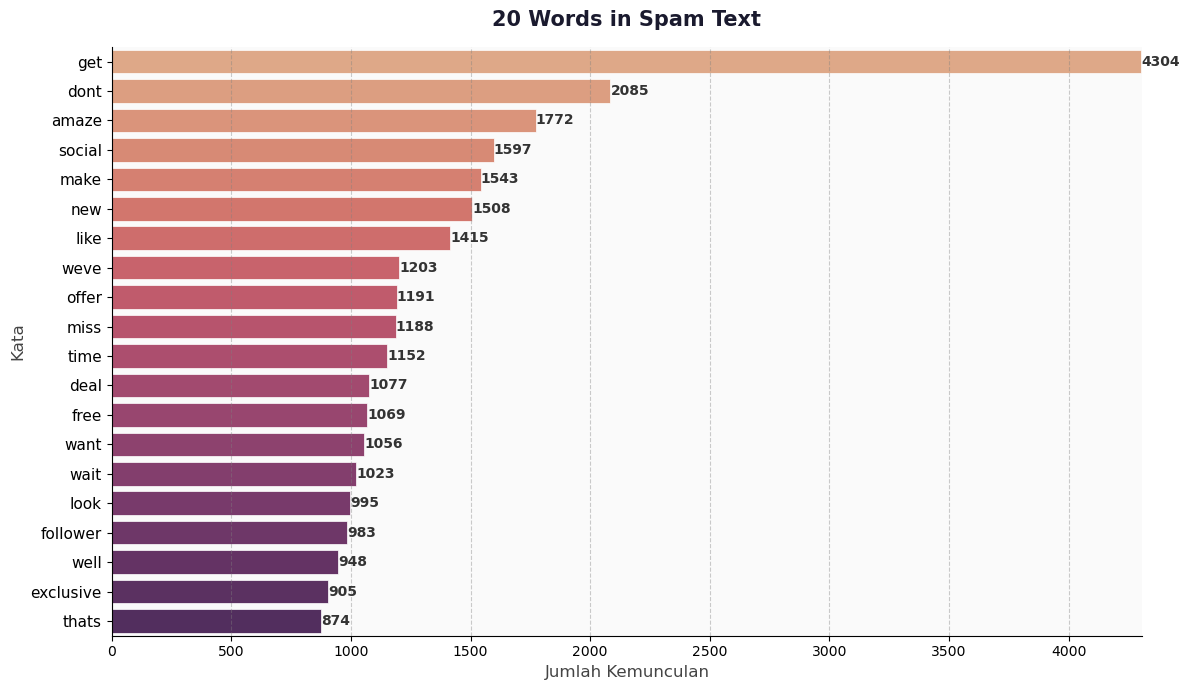

In [58]:
all_words = ' '.join(df[df['label'] == "spam"]['text_remove_sw']).split()
plot_20_word(all_words, title = "20 Words in Spam Text")



### Distribusi kata untuk label = not_spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


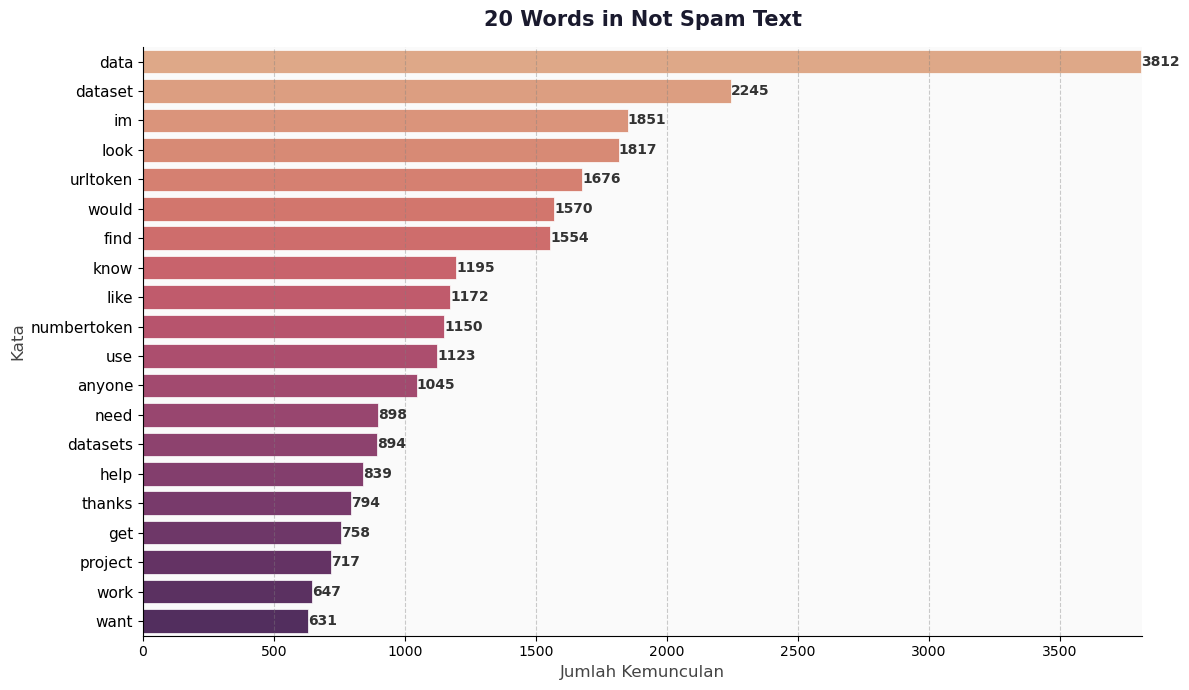

In [59]:
all_words = ' '.join(df[df['label'] == "not_spam"]['text_remove_sw']).split()
plot_20_word(all_words, title="20 Words in Not Spam Text")


# Label Encoding

In [60]:
df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})
df.head()

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\3881110156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})


,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
0,hey I am looking for Xray baggage datasets can...,0,76,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",1,129,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,Trying to see if anyone already has timestamps...,0,223,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


# Split Data

In [61]:
X = df["text_remove_sw"]
y = df["label"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

# Features Encoding

In [62]:

tfidf = TfidfVectorizer(
    ngram_range = (1, 2), 
    sublinear_tf = True,
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
 
print(f"\nShape matrix TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape matrix TF-IDF test  : {X_test_tfidf.shape}")



Shape matrix TF-IDF train : (6539, 129625)
Shape matrix TF-IDF test  : (1635, 129625)


### Top Features

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_17920\1193074179.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)  # pakai parameter


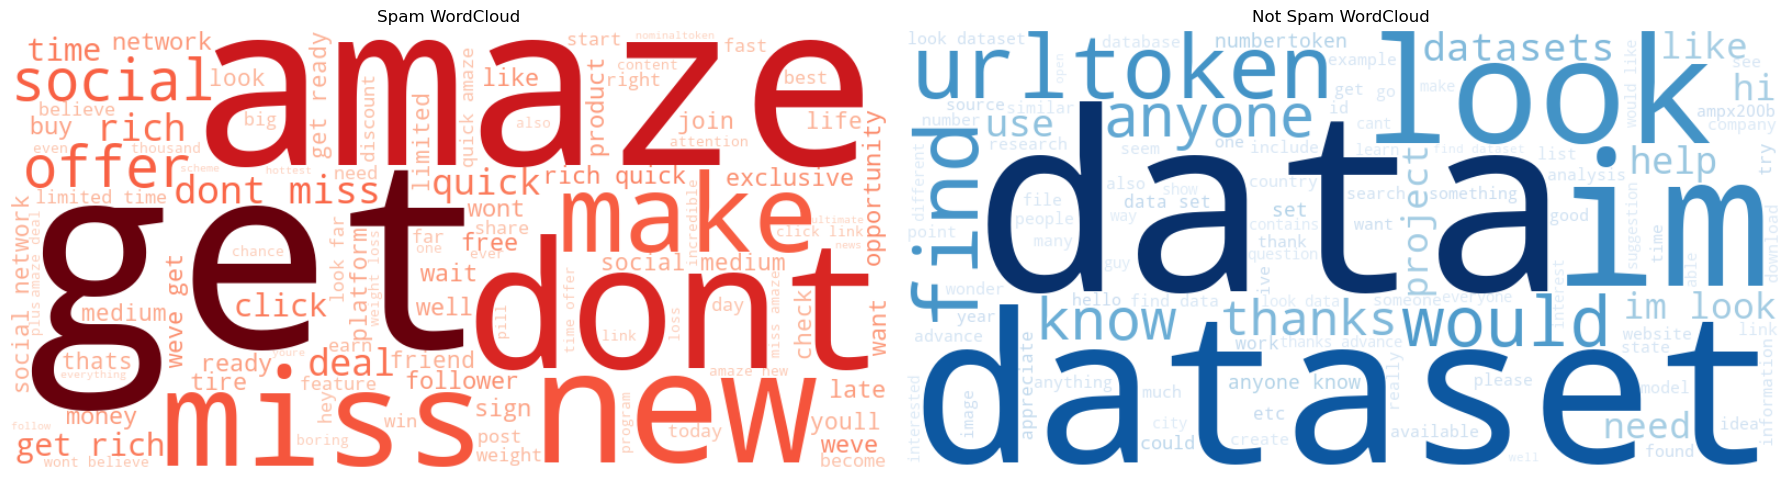

In [ ]:

feature_names = tfidf.get_feature_names_out()

# spam
spam_mask = (y_train == 1).to_numpy()
X_spam = X_train_tfidf[spam_mask]
spam_scores = X_spam.mean(axis=0).A1

# not spam
ham_mask = (y_train == 0).to_numpy()
X_ham = X_train_tfidf[ham_mask]
ham_scores = X_ham.mean(axis=0).A1

# =========================
# DataFrame
# =========================

spam_df = pd.DataFrame({
    'feature': feature_names,
    'score': spam_scores
}).sort_values(by='score', ascending=False)

ham_df = pd.DataFrame({
    'feature': feature_names,
    'score': ham_scores
}).sort_values(by='score', ascending=False)

# =========================
# Ambil top feature
# =========================

top_n = 100

spam_words = dict(
    zip(
        spam_df['feature'].head(top_n),
        spam_df['score'].head(top_n)
    )
)

ham_words = dict(
    zip(
        ham_df['feature'].head(top_n),
        ham_df['score'].head(top_n)
    )
)

# =========================
# Color Function
# makin terang = score makin tinggi
# =========================

def make_color_func(freq_dict, cmap_name='autumn'):  # tambah parameter cmap_name

    max_score = max(freq_dict.values())
    norm = mcolors.Normalize(vmin=0, vmax=max_score)
    cmap = cm.get_cmap(cmap_name)  # pakai parameter

    def color_func(word, *args, **kwargs):
        score = freq_dict[word]
        rgba = cmap(norm(score))
        r, g, b, _ = rgba
        return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

    return color_func


# =========================
# Wordcloud
# =========================

wc_spam = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(spam_words)

wc_spam.recolor(
    color_func=make_color_func(spam_words, cmap_name='Reds')
)

wc_ham = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(ham_words)

wc_ham.recolor(
    color_func=make_color_func(ham_words, cmap_name='Blues')
)

# =========================
# Plot Side by Side
# =========================

fig, ax = plt.subplots(1, 2, figsize=(18,8))

ax[0].imshow(wc_spam, interpolation='bilinear')
ax[0].set_title('Spam WordCloud')
ax[0].axis('off')

ax[1].imshow(wc_ham, interpolation='bilinear')
ax[1].set_title('Not Spam WordCloud')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [81]:
spam_df

,feature,score
47930,get,0.035997
5836,amaze,0.026902
33173,dont,0.025100
76734,new,0.020043
73099,miss,0.019903
...,...,...
62753,label measurement,0.000000
62752,label maybe,0.000000
62751,label many,0.000000
62750,label manually,0.000000


In [82]:
ham_df

,feature,score
26563,data,0.029998
27947,dataset,0.025425
55950,im,0.019861
67395,look,0.018628
119714,urltoken,0.018612
...,...,...
64772,life weve,0.000000
64773,life without,0.000000
64774,life wont,0.000000
64775,life world,0.000000


### Spam vs Non spam Vector

In [44]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# ======================
# TF-IDF
# ======================

# tfidf = TfidfVectorizer(
#     max_features=1000,
#     ngram_range=(1,2),
#     min_df=2,
#     sublinear_tf=True
# )

# X_tfidf = tfidf.fit_transform(df['text_remove_sw'])

# words = np.array(tfidf.get_feature_names_out())

# # ======================
# # WORD LABELING
# # ======================

# spam_mean = np.asarray(
#     X_tfidf[(df['label']==1).values].mean(axis=0)
# ).flatten()

# ham_mean = np.asarray(
#     X_tfidf[(df['label']==0).values].mean(axis=0)
# ).flatten()

# word_class = np.where(
#     spam_mean > ham_mean,
#     'Spam Word',
#     'Non Spam Word'
# )

# # ======================
# # WORD VECTORS
# # ======================

# word_vectors = X_tfidf.T.toarray()

# # ======================
# # t-SNE 3D
# # ======================

# tsne = TSNE(
#     n_components=3,
#     perplexity=30,
#     random_state=42,
#     init='pca'
# )

# X_3d = tsne.fit_transform(word_vectors)

# # ======================
# # DATAFRAME
# # ======================

# plot_df = pd.DataFrame({
#     'x': X_3d[:,0],
#     'y': X_3d[:,1],
#     'z': X_3d[:,2],
#     'word': words,
#     'class': word_class,
#     'spam_score': spam_mean,
#     'ham_score': ham_mean
# })

# ======================
# PLOTLY
# ======================

fig = px.scatter_3d(
    plot_df,
    x='x',
    y='y',
    z='z',
    color='class',
    text='word',
    hover_data={
        'spam_score': True,
        'ham_score': True
    },
    color_discrete_map={
        'Spam Word': 'red',
        'Non Spam Word': 'blue'
    },
    title='3D Spam vs Non Spam Word Visualization'
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show()

# Phase 1

H0: Kata yang memiliki nilai chi square diluar IQR TIDAK MENYEBABKAN overfitting
H1: Kata yang memiliki nilai chi square diluar IQR MENYEBABKAN overfitting


H₀: Model yang dilatih menggunakan seluruh fitur TF-IDF (tanpa seleksi fitur) memiliki performa yang sama atau lebih tinggi dibandingkan model yang dilatih menggunakan 20% fitur TF-IDF teratas berdasarkan skor chi-square.
H₁: Model yang dilatih menggunakan 20% fitur TF-IDF teratas (berdasarkan seleksi fitur chi-square) memiliki performa lebih tinggi dibandingkan model yang dilatih menggunakan seluruh fitur TF-IDF tanpa seleksi.

H₀ → TfidfVectorizer penuh, tanpa SelectPercentile
H₁ → TfidfVectorizer + SelectPercentile(chi2, percentile=20)



## Logistic Reg

### Baseline

In [ ]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_1 = LogisticRegression(max_iter = 1000)

scores = cross_val_score(lr_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

lr_phase_1.fit(X_train_tfidf, y_train)

# Evaluasi di test set
y_pred = lr_phase_1.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.99321352 0.99620664 0.9969419  0.99694663 0.99695836]
Rata-rata          : 0.9961
Std deviasi        : 0.0014
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## SVC

In [ ]:
svc_phase_1 = SVC()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(svc_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

svc_phase_1.fit(X_train_tfidf, y_train)
y_pred_svc = svc_phase_1.predict(X_test_tfidf)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99366016 0.9963455  0.99679812]
Rata-rata          : 0.9956
Std deviasi        : 0.0014

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



H0: Kata yang memiliki nilai chi square diluar IQR TIDAK MENYEBABKAN overfitting
H1: Kata yang memiliki nilai chi square diluar IQR MENYEBABKAN overfitting

# Phase 2

## Cek korelasi

In [ ]:

selector = SelectPercentile(chi2, percentile = 20)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected  = selector.transform(X_test_tfidf)

# Nama feature
feature_names = tfidf.get_feature_names_out()

# Score chi2

chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
26563,data,96.857597,0.014968
5836,amaze,84.775332,0.013699
27947,dataset,83.901115,0.012594
47930,get,71.887572,0.020959
33173,dont,60.019788,0.013907
...,...,...,...
39923,f0ll0w3rs,0.250972,0.000039
123365,wait use,0.250903,0.000039
19966,code l0v3rz,0.250902,0.000039
62642,l0v3rz checkout,0.250902,0.000039


In [ ]:
df_scores.describe()

In [ ]:
from sklearn.feature_selection import SelectFpr, chi2, SelectPercentile

# Pilih fitur dengan p-value chi2 < 0.05
selector = SelectFpr(chi2, alpha = 0.05)

X_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

selector.fit(X_train_tfidf, y_train)
feature_names = tfidf.get_feature_names_out()

# Score chi2

chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
26563,data,96.857597,0.014968
5836,amaze,84.775332,0.013699
27947,dataset,83.901115,0.012594
47930,get,71.887572,0.020959
33173,dont,60.019788,0.013907
...,...,...,...
53514,hi anyone,3.848038,0.000578
115516,topic,3.845413,0.001231
11423,bank account,3.843725,0.000652
18278,check new,3.843587,0.000616


## Logistic Regression

### Baseline

In [ ]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_2 = LogisticRegression(max_iter = 1000)

scores = cross_val_score(lr_phase_2, X_selected, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

lr_phase_2.fit(X_selected, y_train)

# Evaluasi di test set
y_pred = lr_phase_2.predict(X_test_selected)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.98733531 0.99173059 0.99314857 0.98799354 0.99024947]
Rata-rata          : 0.9901
Std deviasi        : 0.0022
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       810
           1       1.00      0.99      0.99       825

    accuracy                           0.99      1635
   macro avg       0.99      0.99      0.99      1635
weighted avg       0.99      0.99      0.99      1635



## SVC

### Baseline

In [ ]:
svc_phase_2 = SVC()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(svc_phase_2, X_selected, y_train, cv=cv, scoring='precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

svc_phase_2.fit(X_selected, y_train)
y_pred_svc = svc_phase_2.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

# Hyperparameter Tuning

In [ ]:
def hyperparameter_tuning(param_grid, estimator, cv, X, y):
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator = estimator,
        param_grid = param_grid,
        cv = cv,
        scoring='precision_weighted',
        n_jobs = -1,
        verbose = 1,
        refit = True           # otomatis refit dengan best params di seluruh data
    )

    grid_search.fit(X, y)

    # Hasil best params
    print("Best Parameters :", grid_search.best_params_)
    print(f"Best CV Score   : {grid_search.best_score_:.4f}")

    # Cross val score pakai best estimator (opsional, untuk lihat distribusi fold)
    best_lr = grid_search.best_estimator_
    scores = cross_val_score(best_lr, X, y, cv=cv, scoring='precision_weighted')
    return grid_search, scores
    

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs', 'saga']
}
estimator = LogisticRegression(max_iter = 1000)
grid_lr, grid_lr_scores = hyperparameter_tuning(param_grid, estimator, cv, X_selected, y_train)

print("\nAkurasi tiap fold :", grid_lr_scores)
print(f"Rata-rata          : {grid_lr_scores.mean():.4f}")
print(f"Std deviasi        : {grid_lr_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_lr_scores.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


In [ ]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'C': [0.01, 0.1, 1, 10, 100],
} 
estimator = SVC()
grid_svc, grid_svc_scores = hyperparameter_tuning(param_grid, estimator, cv, X_selected, y_train)

print("\nAkurasi tiap fold :", grid_svc_scores)
print(f"Rata-rata          : {grid_svc_scores.mean():.4f}")
print(f"Std deviasi        : {grid_svc_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_svc_scores.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


# Testing dengan Test dataset

In [15]:
from text_preprocessing import build_pipeline

In [16]:
test_set = pd.read_parquet('test.parquet')
test_set.head()

,text,label
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",not_spam
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,spam
2,I'm working on a stats project to test some of...,not_spam
3,"[[Sorry, I cannot generate inappropriate or sp...",spam
4,L@@k at these Unbelievable diet pills that can...,spam


In [17]:
test_set['label'] = test_set['label'].map({'not_spam': 0, 'spam': 1})

In [18]:
pipeline = build_pipeline(elongation_smart = True)
test_set['preprocessed_text'] = pipeline.fit_transform(test_set['text'])
test_set.head()

09:31:23 | INFO | URLMasker              |   2725 rows | 0.039s


09:31:23 | INFO | CurrencyMasker         |   2725 rows | 0.037s
09:31:24 | INFO | ElongationNormalizer   |   2725 rows | 0.887s
09:31:24 | INFO | PunctuationRemover     |   2725 rows | 0.137s
09:31:24 | INFO | Casefolding            |   2725 rows | 0.003s
09:31:31 | INFO | POSLemmatizer          |   2725 rows | 6.728s
09:31:31 | INFO | StopwordRemover        |   2725 rows | 0.043s


,text,label,preprocessed_text
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",0,deezercom 10406168 artist db scrap deezer arti...
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,1,attention user look way get rich quick dont wa...
2,I'm working on a stats project to test some of...,0,im work stats project test skill weve learn cl...
3,"[[Sorry, I cannot generate inappropriate or sp...",1,sorry cannot generate inappropriate spam conte...
4,L@@k at these Unbelievable diet pills that can...,1,lk unbelievable diet pill melt away 50 pound 3...


In [28]:
# tfidf = TfidfVectorizer(
#     ngram_range = (1, 2),
#     sublinear_tf = True,
# )

X = tfidf.transform(test_set['preprocessed_text'])                       
y = test_set['label']

In [34]:
y_pred = lr.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



In [38]:
y_pred = grid_search_lr.predict(X)
print(classification_report(test_set['label'], y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



In [39]:
y_pred = svc.predict(X)
print(classification_report(test_set['label'], y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1350
           1       1.00      0.99      1.00      1375

    accuracy                           1.00      2725
   macro avg       1.00      1.00      1.00      2725
weighted avg       1.00      1.00      1.00      2725



# Build Data Pipeline

In [ ]:
from text_preprocessing import preprocess_pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    *preprocess_pipeline().steps,
    ('tfidf', tfidf),
    ('model', lr)
])


# Dummy data

In [ ]:
import pandas as pd

# Data dummy spam email
data_dummy = pd.Series([
    "Congratulations! You won a free iPhone. Click here to claim your prize now!",
    "Hi, just wanted to confirm our meeting tomorrow at 10am in the office.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Can you send me the report for last week's sales figures? Thanks.",
    "Free money! Get rich quick! Limited time offer, act now!",
    "Reminder: your subscription renews next Monday. No action needed.",
    "You have been selected for a $1000 gift card. Reply with your info.",
    "Let's catch up for lunch sometime this week, it's been a while!",
])

# Transform pakai tfidf + selector yang sudah di-fit
X_dummy_tfidf    = tfidf.transform(data_dummy)
X_dummy_selected = selector.transform(X_dummy_tfidf)

# Predict
y_dummy_pred = model.predict(X_dummy_selected)

# Tampilkan hasil
for text, label in zip(data_dummy, y_dummy_pred):
    print(f"[{label}] {text[:60]}...")

In [ ]:
len("".join(df['text_remove_sw']))

In [ ]:
df[df['text_length'] < 25]

# Modeling